# 🌱 Full Soil Analysis Pipeline Notebook
This notebook covers:
- NPK Prediction
- Crop Recommendation
- Fertilizer Recommendation
- End-to-End Pipeline


In [1]:
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score


## NPK Model

In [3]:
data = pd.read_csv('../backend/dataset/soil_dataset.csv')
X = data[['mean_r','mean_g','mean_b','mean_h','mean_s','mean_v']]
y = data[['N','P','K']]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
pca = PCA(n_components=3)
X_train_p = pca.fit_transform(X_train_s)
X_test_p = pca.transform(X_test_s)
npk_model = RandomForestRegressor(n_estimators=200)
npk_model.fit(X_train_p,y_train)
pred = npk_model.predict(X_test_p)
print('R2:', r2_score(y_test,pred))


R2: 0.22166995482137675


## Crop Recommendation Model

In [4]:
crop = pd.read_csv('../backend/dataset/Crop_recommendation.csv')
Xc = crop.drop('label',axis=1)
yc = crop['label']
X_train,X_test,y_train,y_test = train_test_split(Xc,yc,test_size=0.2)
crop_model = RandomForestClassifier()
crop_model.fit(X_train,y_train)
print('Accuracy:', crop_model.score(X_test,y_test))


Accuracy: 0.990909090909091


## Fertilizer Model

In [6]:
fert = pd.read_csv('../backend/dataset/fertilizer.csv')
Xf = fert.drop('Fertilizer Name',axis=1)
yf = fert['Fertilizer Name']
Xf = pd.get_dummies(Xf)
X_train,X_test,y_train,y_test = train_test_split(Xf,yf,test_size=0.2)
fert_model = RandomForestClassifier()
fert_model.fit(X_train,y_train)
print('Accuracy:', fert_model.score(X_test,y_test))


Accuracy: 1.0


## End-to-End Pipeline

In [11]:
sample = pd.DataFrame([{
    "mean_r": 120,
    "mean_g": 130,
    "mean_b": 110,
    "mean_h": 0.5,
    "mean_s": 0.6,
    "mean_v": 0.7
}])

sample_s = scaler.transform(sample)
sample_p = pca.transform(sample_s)

npk = npk_model.predict(sample_p)[0]
print("Predicted NPK:", npk)

crop_input = pd.DataFrame([{
    "N": npk[0],
    "P": npk[1],
    "K": npk[2],
    "temperature": 25,
    "humidity": 80,
    "ph": 6.5,
    "rainfall": 200
}])

crop_pred = crop_model.predict(crop_input)
print("Crop:", crop_pred)

Predicted NPK: [23.5795 34.001  56.11  ]
Crop: ['coconut']


## 5️⃣ Save Models

In [14]:
os.makedirs('./models',exist_ok=True)
pickle.dump(npk_model,open('./models/npk_model.pkl','wb'))
pickle.dump(crop_model,open('./models/crop_model.pkl','wb'))
pickle.dump(fert_model,open('./models/fertilizer_model.pkl','wb'))
pickle.dump(pca,open('./models/pca_model.pkl','wb'))
pickle.dump(scaler,open('./models/scaler.pkl','wb'))
print('All models saved')


All models saved


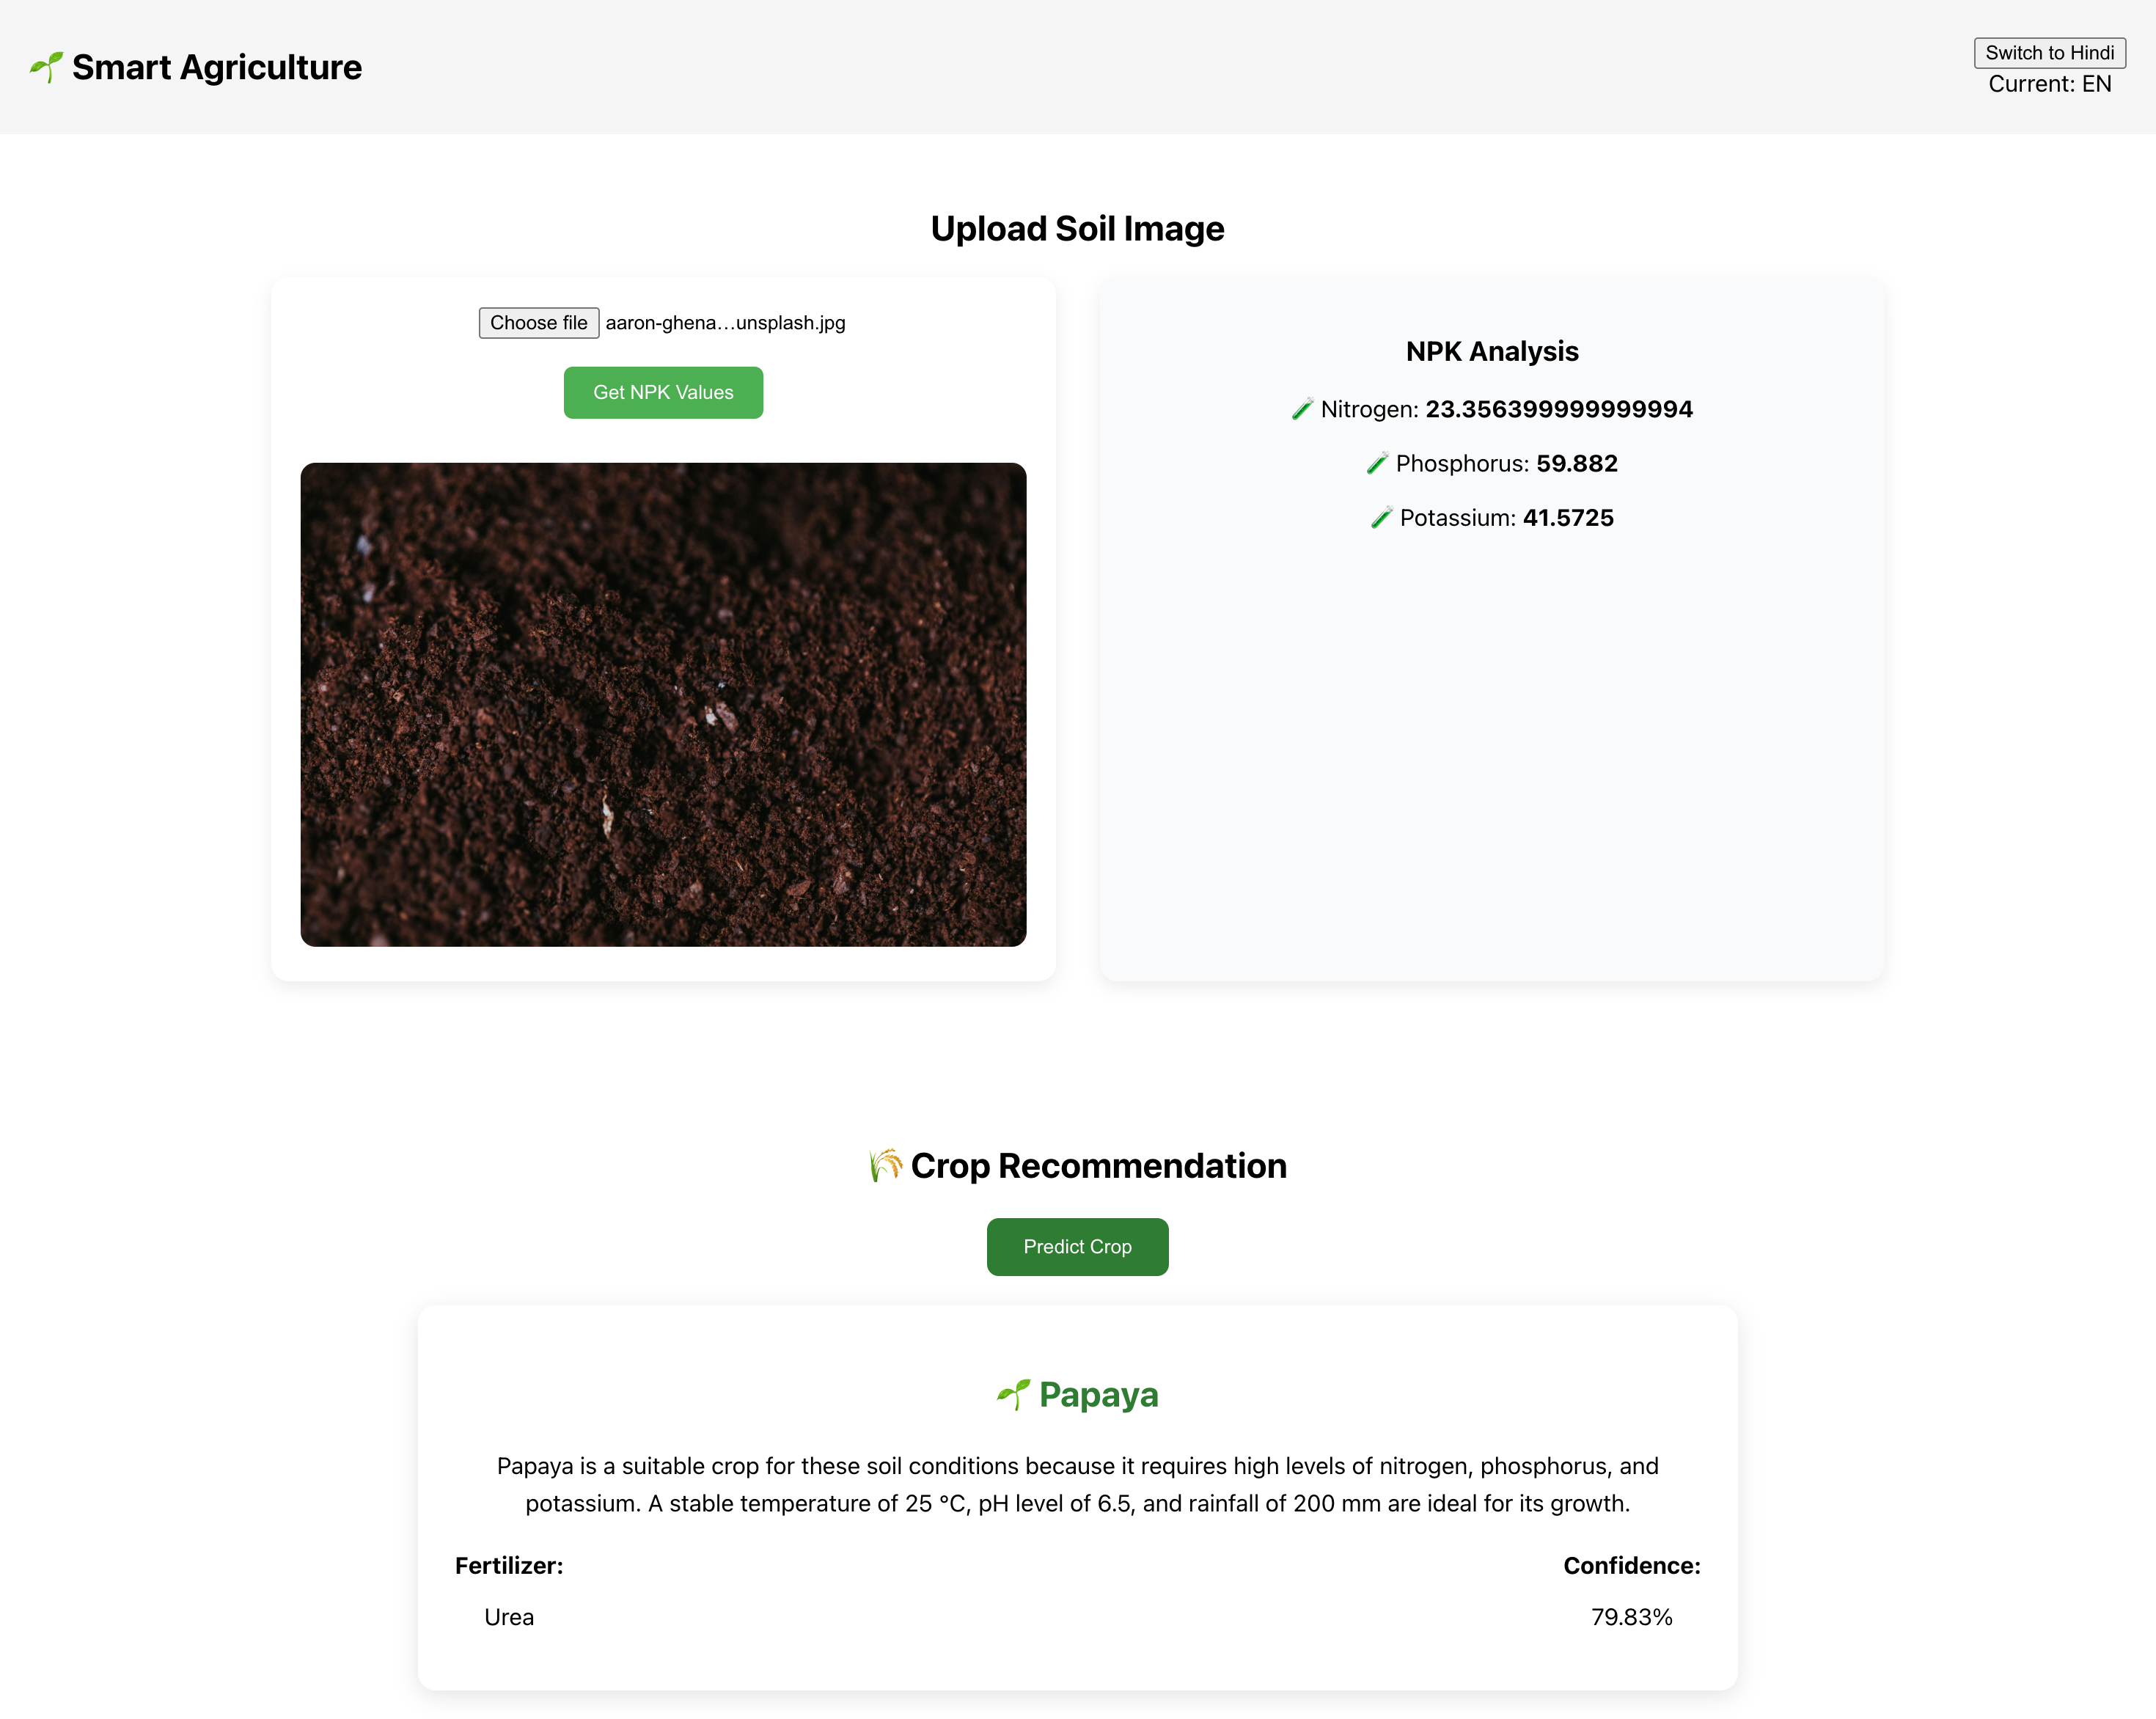